In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pennylane --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 114.6 MB/s eta 0:00:00


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("/content/drive/MyDrive/kaggle_datasets/zero_day/zero_day_attack_detection_dataset_V1-400k.csv",nrows=10000)

In [5]:
df.head()

,Time,Protocol,Flag,Family,Clusters,SeddAddress,ExpAddress,BTC,USD,Netflow Bytes,...,Application Layer Data,User-Agent,Geolocation,Logistics ID,Anomaly Score,Event Description,Response Time,Session ID,Data Transfer Rate,Error Code
0,1/1/2020 0:01,TCP,SYN,WannaCry,1,99.16.139.75,95.167.221.79,0.27,746.01,3033,...,POST /exploit,Mozilla/5.0 (Windows NT 10.0; Win64; x64),Airport ABC,LGT99002,0.94,Suspicious Activity,458 ms,SESS1197,11.54 Mbps,500
1,1/1/2020 0:08,UDP,ACK,SQL Injection,1,12.157.236.35,178.245.197.204,0.56,887.49,8428,...,POST /exploit,Mozilla/5.0 (Windows NT 10.0; Win64; x64),Airport XYZ,LGT28397,0.65,Suspicious Activity,549 ms,SESS8276,18.12 Mbps,500
2,1/1/2020 0:14,TCP,SYN,SQL Injection,4,30.133.10.160,30.123.19.186,0.04,240.92,2590,...,GET /malicious,Mozilla/5.0 (Windows NT 10.0; Win64; x64),Airport XYZ,LGT91916,0.82,Suspicious Activity,594 ms,SESS5549,7.29 Mbps,403
3,1/1/2020 0:19,UDP,FIN,Normal,4,63.167.183.21,77.154.202.8,0.62,962.23,3798,...,QUERY /info,Mozilla/5.0,Airport DEF,LGT67265,0.07,Data Query,70 ms,SESS9986,6.79 Mbps,200
4,1/1/2020 0:25,TCP,SYN,SQL Injection,1,48.176.214.218,62.86.203.121,0.41,995.56,10574,...,POST /exploit,Mozilla/5.0 (Windows NT 10.0; Win64; x64),Airport ABC,LGT75468,0.69,Suspicious Activity,524 ms,SESS9976,4.56 Mbps,404


In [6]:
from sklearn.preprocessing import LabelEncoder


cols_to_drop = ['Time', 'SeddAddress', 'ExpAddress', 'Logistics ID', 'Session ID', 'User-Agent', 'Geolocation', 'Application Layer Data', 'Event Description']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


if df['Response Time'].dtype == 'object':
    df['Response Time'] = df['Response Time'].str.replace(' ms', '').astype(float)
if df['Data Transfer Rate'].dtype == 'object':
    df['Data Transfer Rate'] = df['Data Transfer Rate'].str.replace(' Mbps', '').astype(float)


le = LabelEncoder()

categorical_cols = ['Protocol', 'Flag', 'Family', 'IP Address', 'Threat Level', 'Prediction']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))


print("Final Preprocessed Data Shape:", df.shape)
print("Data Types:")
print(df.dtypes)
display(df.head())

Final Preprocessed Data Shape: (10000, 17)
Data Types:
Protocol                int64
Flag                    int64
Family                  int64
Clusters                int64
BTC                   float64
USD                   float64
Netflow Bytes           int64
IP Address              int64
Threat Level            int64
Port                    int64
Prediction              int64
Payload Size            int64
Number of Packets       int64
Anomaly Score         float64
Response Time         float64
Data Transfer Rate    float64
Error Code              int64
dtype: object


,Protocol,Flag,Family,Clusters,BTC,USD,Netflow Bytes,IP Address,Threat Level,Port,Prediction,Payload Size,Number of Packets,Anomaly Score,Response Time,Data Transfer Rate,Error Code
0,0,2,4,1,0.27,746.01,3033,5295,1,21,0,1335,5,0.94,458.0,11.54,500
1,1,0,3,1,0.56,887.49,8428,5898,1,21,0,587,2,0.65,549.0,18.12,500
2,0,2,3,4,0.04,240.92,2590,7460,1,443,0,941,5,0.82,594.0,7.29,403
3,1,1,1,4,0.62,962.23,3798,3654,0,80,1,861,4,0.07,70.0,6.79,200
4,0,2,3,1,0.41,995.56,10574,3720,1,80,0,1479,9,0.69,524.0,4.56,404


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier



TARGET_COL = "Threat Level"
DROP_COLS  = ["Threat Level", "Prediction"]


class_counts = df[TARGET_COL].value_counts()
print(class_counts)

ZERO_DAY_CLASSES = [class_counts.idxmin()]
print(f"Holding out as zero-day: {ZERO_DAY_CLASSES}")

known_df   = df[~df[TARGET_COL].isin(ZERO_DAY_CLASSES)].copy()
zeroday_df = df[df[TARGET_COL].isin(ZERO_DAY_CLASSES)].copy()

X_known = known_df.drop(columns=DROP_COLS)
y_known = known_df[TARGET_COL].astype("category").cat.codes.values
label_map = dict(enumerate(known_df[TARGET_COL].astype("category").cat.categories))

X_zeroday = zeroday_df.drop(columns=DROP_COLS)


X_train, X_temp, y_train, y_temp = train_test_split(
    X_known, y_known, test_size=0.4, stratify=y_known, random_state=42)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"train={len(X_train)}  cal={len(X_cal)}  test(known)={len(X_test)}  zero-day={len(X_zeroday)}")

Threat Level
0    6212
1    3788
Name: count, dtype: int64
Holding out as zero-day: [np.int64(1)]
train=3727  cal=1242  test(known)=1243  zero-day=3788


In [8]:
N_QUBITS = 6

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
top_features = X_train.columns[np.argsort(rf.feature_importances_)[::-1][:N_QUBITS]]
print("Selected features:", list(top_features))

scaler = StandardScaler()
X_train_r = scaler.fit_transform(X_train[top_features])
X_cal_r   = scaler.transform(X_cal[top_features])
X_test_r  = scaler.transform(X_test[top_features])
X_zday_r  = scaler.transform(X_zeroday[top_features])

def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi

A_train, A_cal, A_test, A_zday = map(to_angles, [X_train_r, X_cal_r, X_test_r, X_zday_r])

Selected features: ['Error Code', 'Data Transfer Rate', 'Response Time', 'Anomaly Score', 'Number of Packets', 'Payload Size']


In [9]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import WeightedRandomSampler

N_QUBITS    = 4
N_LAYERS    = 3
NOISE_P     = 0.01
LAMBDA1_MAX = 0.5
LAMBDA2_MAX = 0.1
LR          = 0.05
EPOCHS      = 10
BATCH_SIZE  = 16
EMA_MOMENTUM = 0.9
WARMUP_FRAC = 0.2
GRAD_CLIP_NORM = 1.0
FOCAL_GAMMA = 2.0

dev = qml.device("default.mixed", wires=N_QUBITS)




@qml.qnode(dev, interface="torch")
def state_circuit_batched(x_batch, theta):
    """x_batch: (B, n_features). Returns rho: (B, 2^n, 2^n)."""
    n_feat = x_batch.shape[1]
    for layer in range(N_LAYERS):
        for w in range(N_QUBITS):
            qml.RY(x_batch[:, w % n_feat], wires=w)
            qml.RZ(x_batch[:, (w + 1) % n_feat], wires=w)
        for w in range(N_QUBITS):                        # U(theta)
            qml.RY(theta[layer, w, 0], wires=w)
            qml.RZ(theta[layer, w, 1], wires=w)
        for w in range(N_QUBITS):                         # ring entanglement
            qml.CNOT(wires=[w, (w + 1) % N_QUBITS])
        for w in range(N_QUBITS):                          # Lambda_p
            qml.DepolarizingChannel(NOISE_P, wires=w)
    return qml.density_matrix(wires=range(N_QUBITS))


def _build_pauliZ_ops(n_qubits):
    I = torch.eye(2, dtype=torch.cdouble)
    Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.cdouble)
    ops = []
    for w in range(n_qubits):
        mats = [Z if i == w else I for i in range(n_qubits)]
        op = mats[0]
        for m in mats[1:]:
            op = torch.kron(op, m)
        ops.append(op)
    return ops

PAULI_Z_OPS = _build_pauliZ_ops(N_QUBITS)

def expvals_from_rho_batch(rho_batch):
    return torch.stack([
        torch.stack([torch.real(torch.trace(rho @ op)) for op in PAULI_Z_OPS])
        for rho in rho_batch
    ])



def safe_fidelity(r1, r2, eps=1e-7):
    f = qml.math.fidelity(r1, r2)
    return torch.clamp(f, 0.0, 1.0 - eps)

def safe_trace_distance(r1, r2):
    return torch.clamp(qml.math.trace_distance(r1, r2), 0.0, 1.0)



def focal_loss(logits, targets, gamma=FOCAL_GAMMA):
    ce = nn.functional.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()



def curriculum_weight(epoch, total_epochs, base, warmup_frac=WARMUP_FRAC):
    warmup = max(int(warmup_frac * total_epochs), 1)
    return base * min(1.0, epoch / warmup)




def identity_block_init(n_layers, n_qubits):
    return torch.nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 2))


def train_maqt(X_train, y_train, n_classes):
    theta = identity_block_init(N_LAYERS, N_QUBITS)
    head = nn.Linear(N_QUBITS, n_classes)
    opt = torch.optim.Adam(list([theta]) + list(head.parameters()), lr=LR)


    class_counts = np.bincount(y_train.numpy(), minlength=n_classes)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train.numpy()]
    sampler = list(WeightedRandomSampler(sample_weights, num_samples=len(y_train), replacement=True))


    ema_protos = {}

    for epoch in range(EPOCHS):
        lam1 = curriculum_weight(epoch, EPOCHS, LAMBDA1_MAX)
        lam2 = curriculum_weight(epoch, EPOCHS, LAMBDA2_MAX)

        perm = torch.tensor(sampler)
        grad_vars = []

        for i in range(0, len(perm), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            xb, yb = X_train[idx], y_train[idx]


            rho_batch = state_circuit_batched(xb, theta)
            z_batch = expvals_from_rho_batch(rho_batch)
            logits = head(z_batch.to(torch.float32))


            L_CE = focal_loss(logits, yb)


            L_intra_terms = []
            batch_class_means = {}
            for c in torch.unique(yb):
                mask = (yb == c)
                rhos_c = [rho_batch[j] for j in range(len(rho_batch)) if mask[j]]
                batch_mean = sum(rhos_c) / len(rhos_c)
                batch_class_means[int(c)] = batch_mean

                c_int = int(c)
                if c_int not in ema_protos:
                    ema_protos[c_int] = batch_mean.detach()
                else:
                    ema_protos[c_int] = (EMA_MOMENTUM * ema_protos[c_int]
                                          + (1 - EMA_MOMENTUM) * batch_mean.detach())


                for r in rhos_c:
                    L_intra_terms.append(1 - safe_fidelity(r, ema_protos[c_int]))

            L_intra = torch.stack(L_intra_terms).mean()


            keys = list(batch_class_means.keys())
            L_inter_terms = []
            for a in range(len(keys)):
                for b in range(a + 1, len(keys)):
                    L_inter_terms.append(
                        safe_trace_distance(ema_protos[keys[a]], ema_protos[keys[b]])
                    )
            L_inter = -torch.stack(L_inter_terms).mean() if L_inter_terms else torch.tensor(0.0)

            loss = L_CE + lam1 * L_intra + lam2 * L_inter

            opt.zero_grad()
            loss.backward()

            # gradient clipping
            torch.nn.utils.clip_grad_norm_(list([theta]) + list(head.parameters()), GRAD_CLIP_NORM)

            grad_vars.append(theta.grad.var().item())
            opt.step()

        mean_gv = np.mean(grad_vars)
        print(f"epoch {epoch+1:2d} | loss {loss.item():.4f} | "
              f"lam1 {lam1:.3f} | lam2 {lam2:.3f} | grad_var {mean_gv:.2e}")
        if mean_gv < 1e-6:
            print(" barren plateau detected — consider shallower depth or different init")


    return theta, head, ema_protos

In [10]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import WeightedRandomSampler


def compute_nonconformity_scores_batched(X_cal, theta, prototypes, batch_size=32):

    proto_keys = list(prototypes.keys())
    proto_mats = torch.stack([prototypes[c] for c in proto_keys])  # (C, 2^n, 2^n)

    scores = []
    with torch.no_grad():
        for i in range(0, len(X_cal), batch_size):
            xb = X_cal[i:i + batch_size]
            rho_batch = state_circuit_batched(xb, theta)  # (B, 2^n, 2^n)

            for r in rho_batch:
                fids = torch.stack([
                    safe_fidelity(r, proto_mats[k]) for k in range(len(proto_keys))
                ])
                scores.append((1 - fids.max()).item())

    return np.array(scores)


def calibrate_threshold(X_cal, theta, prototypes, alpha=0.05, batch_size=32):

    s = compute_nonconformity_scores_batched(X_cal, theta, prototypes, batch_size)
    s_sorted = np.sort(s)
    n = len(s_sorted)

    if n < int(20 / alpha):
        print(f"calibration set size ({n}) is small relative to alpha={alpha}; "
              f"recommend n >= {int(20/alpha)} for a stable threshold")

    k = int(np.ceil((1 - alpha) * (n + 1)))
    k = min(k, n)
    q = s_sorted[k - 1]
    return q, s_sorted





def estimate_lipschitz(X_sample, theta, n_probe=50, delta=0.05, batch_size=32):

    idx = np.random.choice(len(X_sample), min(n_probe, len(X_sample)), replace=False)
    probes = X_sample[idx]
    perturbed = probes + delta * torch.randn_like(probes)

    ratios = []
    with torch.no_grad():
        for i in range(0, len(probes), batch_size):
            rho1_batch = state_circuit_batched(probes[i:i + batch_size], theta)
            rho2_batch = state_circuit_batched(perturbed[i:i + batch_size], theta)
            for r1, r2 in zip(rho1_batch, rho2_batch):
                d = safe_trace_distance(r1, r2)
                ratios.append(d.item() / delta)

    return max(ratios)





def unified_inference_batched(X, theta, prototypes, q, L_phi, p=NOISE_P, Cf=1.0, batch_size=32):

    proto_keys = list(prototypes.keys())
    proto_mats = torch.stack([prototypes[c] for c in proto_keys])

    results = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i + batch_size]
            rho_batch = state_circuit_batched(xb, theta)

            for r in rho_batch:
                fids = torch.stack([
                    safe_fidelity(r, proto_mats[k]) for k in range(len(proto_keys))
                ])
                sorted_fids, sorted_idx = torch.sort(fids, descending=True)
                f_star = sorted_fids[0].item()
                c_star = proto_keys[sorted_idx[0].item()]
                s = 1 - f_star

                if s > q:
                    results.append(("ZERO_DAY", 0.0))
                else:
                    f_second = sorted_fids[1].item() if len(sorted_fids) > 1 else 0.0
                    margin = f_star - f_second
                    R = margin / (2 * (1 - p) * L_phi * Cf)
                    results.append((c_star, R))

    return results





def run_qsnet_pipeline(X_train, y_train, X_cal, X_test, y_test, X_zeroday,
                        n_classes, alpha=0.05, Cf=1.0):

    print("=== Stage 1-2: MAQT Training ===")
    theta, head, prototypes = train_maqt(X_train, y_train, n_classes)

    print("\n=== Stage 3: Conformal Calibration (CQ-ZDR) ===")
    q, s_sorted = calibrate_threshold(X_cal, theta, prototypes, alpha=alpha)
    print(f"Calibrated threshold q = {q:.4f}  (n_cal={len(s_sorted)}, target alpha={alpha})")

    print("\n=== Estimating encoder Lipschitz constant (for certified radius) ===")
    L_phi = estimate_lipschitz(X_train, theta)
    print(f"L_phi (empirical) ≈ {L_phi:.4f}")

    print("\n=== Stage 4: Inference on known-class test set ===")
    test_results = unified_inference_batched(X_test, theta, prototypes, q, L_phi, Cf=Cf)
    pred_labels = [r[0] for r in test_results]

    false_zd_mask = np.array([lbl == "ZERO_DAY" for lbl in pred_labels])
    false_zd_rate = false_zd_mask.mean()
    print(f"Empirical false-zero-day rate: {false_zd_rate:.3f}  (target <= {alpha})")


    kept_idx = ~false_zd_mask
    if kept_idx.sum() > 0:
        correct = np.array([
            pred_labels[i] == int(y_test[i]) for i in range(len(y_test)) if kept_idx[i]
        ])
        print(f"Accuracy on non-rejected known samples: {correct.mean():.3f} "
              f"({kept_idx.sum()}/{len(y_test)} samples kept)")

    mean_R = np.mean([r[1] for r in test_results if r[0] != "ZERO_DAY"]) if kept_idx.sum() > 0 else 0.0
    print(f"Mean certified radius (accepted samples): {mean_R:.4f}")

    print("\n=== Stage 4: Inference on TRUE zero-day set ===")
    zd_results = unified_inference_batched(X_zeroday, theta, prototypes, q, L_phi, Cf=Cf)
    detection_rate = np.mean([r[0] == "ZERO_DAY" for r in zd_results])
    print(f"Zero-day detection rate: {detection_rate:.3f}")

    return {
        "theta": theta,
        "head": head,
        "prototypes": prototypes,
        "q": q,
        "L_phi": L_phi,
        "false_zd_rate": false_zd_rate,
        "detection_rate": detection_rate,
        "test_results": test_results,
        "zd_results": zd_results,
    }

In [11]:
n_classes = len(np.unique(y_known))

results = run_qsnet_pipeline(
    X_train=torch.tensor(A_train, dtype=torch.float32),
    y_train=torch.tensor(y_train, dtype=torch.long),
    X_cal=torch.tensor(A_cal, dtype=torch.float32),
    X_test=torch.tensor(A_test, dtype=torch.float32),
    y_test=torch.tensor(y_test, dtype=torch.long),
    X_zeroday=torch.tensor(A_zday, dtype=torch.float32),
    n_classes=n_classes,
    alpha=0.05,
    Cf=1.0
)

=== Stage 1-2: MAQT Training ===
epoch  1 | loss 0.0000 | lam1 0.000 | lam2 0.000 | grad_var 0.00e+00
 barren plateau detected — consider shallower depth or different init
epoch  2 | loss 0.0952 | lam1 0.250 | lam2 0.050 | grad_var 8.83e-06
epoch  3 | loss 0.1899 | lam1 0.500 | lam2 0.100 | grad_var 4.39e-05
epoch  4 | loss 0.1900 | lam1 0.500 | lam2 0.100 | grad_var 4.17e-05
epoch  5 | loss 0.1899 | lam1 0.500 | lam2 0.100 | grad_var 4.15e-05
epoch  6 | loss 0.1898 | lam1 0.500 | lam2 0.100 | grad_var 4.18e-05
epoch  7 | loss 0.1897 | lam1 0.500 | lam2 0.100 | grad_var 4.22e-05
epoch  8 | loss 0.1896 | lam1 0.500 | lam2 0.100 | grad_var 4.26e-05
epoch  9 | loss 0.1895 | lam1 0.500 | lam2 0.100 | grad_var 4.30e-05
epoch 10 | loss 0.1894 | lam1 0.500 | lam2 0.100 | grad_var 4.34e-05

=== Stage 3: Conformal Calibration (CQ-ZDR) ===
Calibrated threshold q = 0.5692  (n_cal=1242, target alpha=0.05)

=== Estimating encoder Lipschitz constant (for certified radius) ===
L_phi (empirical) ≈ 4.0

In [12]:
print(results)

{'theta': Parameter containing:
tensor([[[-0.9168,  0.5904],
         [-1.4720, -0.2396],
         [ 0.5343,  1.7127],
         [-1.6431,  0.0083]],

        [[ 1.4665, -0.0528],
         [-0.3533,  1.4523],
         [ 0.0502,  0.2215],
         [-0.4284, -0.1676]],

        [[ 1.6867,  1.2297],
         [-0.2317, -0.1711],
         [-1.3576, -0.7822],
         [ 0.1234,  0.5230]]], requires_grad=True), 'head': Linear(in_features=4, out_features=1, bias=True), 'prototypes': {0: tensor([[ 0.0686+2.9215e-19j, -0.0111+1.2429e-02j, -0.0152-2.7948e-03j,
         -0.0600-2.3347e-02j,  0.0332-2.7782e-02j, -0.0010+2.5819e-02j,
         -0.0131-2.4233e-03j, -0.0182-4.1315e-02j,  0.0198+1.3001e-05j,
          0.0323+3.4529e-02j,  0.0107+4.5267e-02j,  0.0207+3.9195e-03j,
         -0.0116-3.1868e-02j, -0.0272-3.9683e-03j,  0.0283-3.6398e-02j,
         -0.0078+2.1102e-02j],
        [-0.0111-1.2429e-02j,  0.0355-6.6070e-19j,  0.0035+7.1520e-03j,
          0.0103+2.3429e-02j, -0.0155-3.1127e-03j,  0.

### Performance Metrics Visualization

/tmp/ipykernel_1629/2164272241.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_names, y=metric_values, palette='viridis')


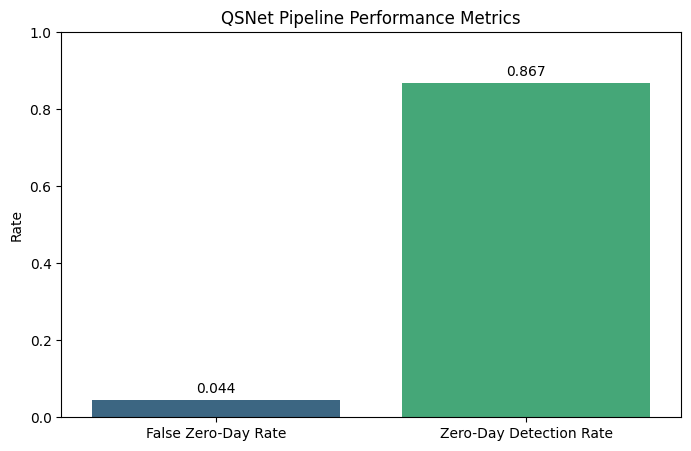

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'False Zero-Day Rate': results['false_zd_rate'],
    'Zero-Day Detection Rate': results['detection_rate']
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

fig = plt.figure(figsize=(8, 5))
sns.barplot(x=metric_names, y=metric_values, palette='viridis')
plt.title('QSNet Pipeline Performance Metrics')
plt.ylabel('Rate')
plt.ylim(0, 1) # Rates are between 0 and 1
for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center')
plt.show()


### Anomaly Score Distribution: Zero-Day vs. Known Samples

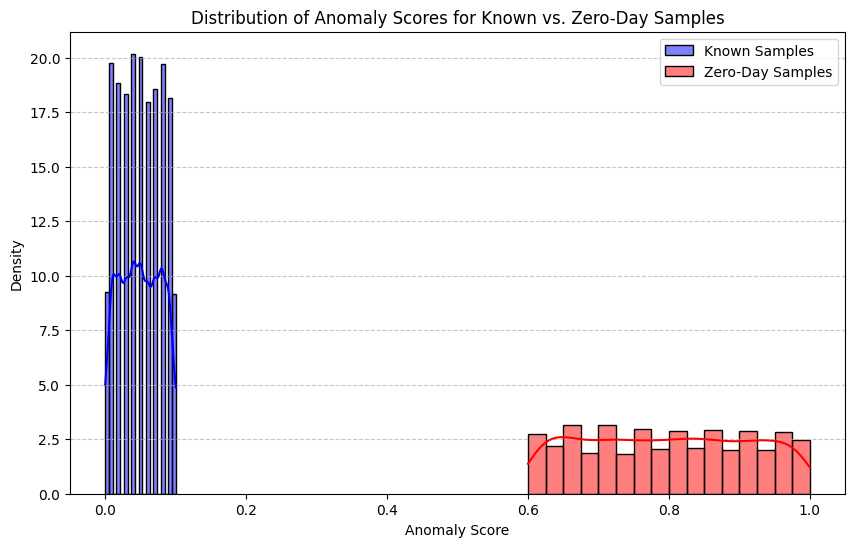

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(X_known['Anomaly Score'], color='blue', label='Known Samples', kde=True, stat='density', alpha=0.5)
sns.histplot(X_zeroday['Anomaly Score'], color='red', label='Zero-Day Samples', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Anomaly Scores for Known vs. Zero-Day Samples')
plt.xlabel('Anomaly Score')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of Certified Radii for Accepted Known Samples

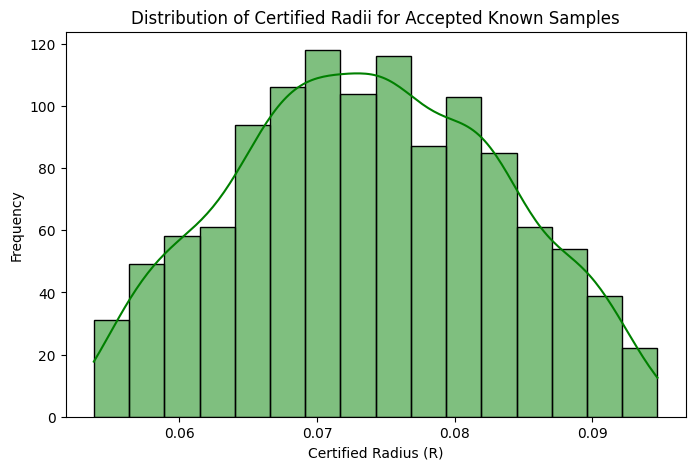

In [15]:
accepted_radii = [r[1] for r in results['test_results'] if r[0] != "ZERO_DAY"]

if accepted_radii:
    plt.figure(figsize=(8, 5))
    sns.histplot(accepted_radii, kde=True, color='green')
    plt.title('Distribution of Certified Radii for Accepted Known Samples')
    plt.xlabel('Certified Radius (R)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("No accepted known samples to plot certified radii for.")

### Anomaly Scores for Missed Zero-Day Samples

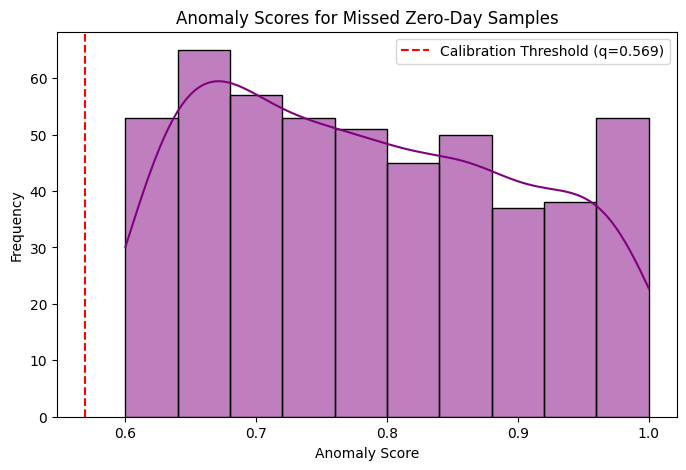

In [16]:
missed_zd_indices = [i for i, r in enumerate(results['zd_results']) if r[0] != "ZERO_DAY"]

if missed_zd_indices:
    missed_zd_anomaly_scores = X_zeroday.iloc[missed_zd_indices]['Anomaly Score']

    plt.figure(figsize=(8, 5))
    sns.histplot(missed_zd_anomaly_scores, kde=True, color='purple')
    plt.title('Anomaly Scores for Missed Zero-Day Samples')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.axvline(x=results['q'], color='r', linestyle='--', label=f'Calibration Threshold (q={results["q"]:.3f})')
    plt.legend()
    plt.show()
else:
    print("All zero-day samples were detected as zero-day, or no zero-day samples to analyze further.")